# Taller LSTM – Parte 1: Limpieza del dataset

**Archivo:** `dataset_demanda_energia_LSTM_2025_2026.csv` · **Periodo:** 2025-01-01 a 2026-12-31 (horario)

El enunciado advierte que el dataset contiene **valores faltantes, anomalías, duplicados, desorden temporal e inconsistencias de texto**. Este notebook los diagnostica y corrige con reglas explícitas, cada una justificada.

**Principios que guían todas las reglas** (tomados de las condiciones del taller):

1. **No inventar valores para corregir anomalías.** Un valor anómalo nunca se reemplaza por un número fabricado (media, valor aleatorio, valor "razonable"). Primero se **marca como faltante** y luego solo se recupera si existe un **valor observado** que lo respalde.
2. **No usar información futura.** Cualquier relleno usa solo el pasado, igual que haría un sistema en tiempo real.
3. **Trazabilidad.** Cada valor modificado queda registrado (fecha, variable, valor original, valor nuevo, regla) en `outputs/reports/cleaning_changes.csv`.

In [1]:
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

RAW_PATH = Path("dataset_demanda_energia_LSTM_2025_2026.csv")
DATA_DIR = Path("data")
REPORT_DIR = Path("outputs/reports")
FIG_DIR = Path("outputs/figures")
for directory in (DATA_DIR, REPORT_DIR, FIG_DIR):
    directory.mkdir(parents=True, exist_ok=True)
CLEAN_PATH = DATA_DIR / "energy_demand_clean.csv"

TIMESTAMP_FORMAT = "%Y-%m-%d %H:%M:%S"
NUMERIC_COLS = ["demanda_mw", "temperatura_c", "humedad_pct", "viento_kmh", "radiacion_wm2",
                "precipitacion_mm", "precio_kwh", "demanda_objetivo"]
INTEGER_COLS = ["hora", "dia_semana", "fin_semana", "festivo", "mes"]
EXOGENOUS_COLS = ["temperatura_c", "humedad_pct", "viento_kmh", "radiacion_wm2", "precipitacion_mm", "precio_kwh"]
SPIKE_CHECK_COLS = ["temperatura_c", "humedad_pct", "viento_kmh", "precio_kwh"]

COLOR_MAIN = "#2a78d6"
COLOR_SECONDARY = "#eb6834"
COLOR_ANOMALY = "#d03b3b"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.6,
    "axes.edgecolor": "#8a8984", "axes.titleweight": "bold", "lines.linewidth": 1.0,
})

cleaning_log = []     # one row per rule applied
change_records = []   # one row per modified value


def log_step(step, rule, rationale, affected):
    cleaning_log.append({"paso": step, "regla": rule, "justificacion": rationale,
                         "registros_afectados": int(affected)})
    print(f"[{step}] {rule}: {int(affected)} registros afectados")


def record_changes(frame, mask, column, rule, new_values):
    new_series = pd.Series(new_values, index=frame.index) if np.isscalar(new_values) else new_values
    change_records.append(pd.DataFrame({
        "timestamp": frame.loc[mask, "timestamp"].to_numpy(),
        "variable": column,
        "valor_original": frame.loc[mask, column].astype(object).to_numpy(),
        "valor_nuevo": new_series.loc[mask].astype(object).to_numpy(),
        "regla": rule,
    }))

## 0. Diagnóstico del archivo original

Se lee **todo como texto** (`dtype=str`) para ver los problemas tal como vienen, sin que pandas los oculte al convertir tipos.

In [2]:
raw_df = pd.read_csv(RAW_PATH, dtype=str, keep_default_na=False, encoding="utf-8")
print(f"Filas: {raw_df.shape[0]:,} | Columnas: {raw_df.shape[1]}")
raw_df.head()

Filas: 17,550 | Columnas: 15


,timestamp,demanda_mw,temperatura_c,humedad_pct,viento_kmh,radiacion_wm2,precipitacion_mm,precio_kwh,hora,dia_semana,fin_semana,festivo,mes,periodo_dia,demanda_objetivo
0,2025-05-11 08:00:00,578.27,19.94,52.31,12.98,445.51,0.0,29.5028,8,6,1,0,5,mañana,573.67
1,2026-07-21 05:00:00,734.79,21.51,61.71,16.04,0.0,4.56,18.9739,5,1,0,0,7,madrugada,758.59
2,2025-08-21 00:00:00,698.8,24.0,94.25,16.15,0.0,0.0,18.9476,0,3,0,0,8,madrugada,705.37
3,2025-08-18 17:00:00,787.4,24.39,63.25,6.15,83.32,0.0,31.7882,17,0,0,0,8,tarde,804.35
4,2026-04-19 09:00:00,522.11,19.65,55.63,14.01,556.14,0.0,35.2807,9,6,1,0,4,mañana,526.36


In [3]:
def diagnose(frame):
    rows = []
    for col in frame.columns:
        values = frame[col]
        empty = (values.str.strip() == "").sum()
        is_text_col = col in ("timestamp", "periodo_dia")
        non_numeric = np.nan if is_text_col else pd.to_numeric(values, errors="coerce").isna().sum() - empty
        rows.append({"columna": col, "vacios": empty, "no_numericos": non_numeric,
                     "valores_unicos": values.nunique()})
    return pd.DataFrame(rows).set_index("columna")


raw_timestamps = pd.to_datetime(raw_df["timestamp"], format=TIMESTAMP_FORMAT, errors="coerce")
print("Timestamps no parseables :", raw_timestamps.isna().sum())
print("Filas duplicadas exactas :", raw_df.duplicated().sum())
print("Timestamps repetidos     :", raw_timestamps.duplicated().sum())
backward_jumps = (raw_timestamps.diff() < pd.Timedelta(0)).mean()
print(f"¿Orden cronológico?      : {raw_timestamps.is_monotonic_increasing} "
      f"({backward_jumps:.1%} de las filas retroceden en el tiempo)")
diagnose(raw_df)

Timestamps no parseables : 0
Filas duplicadas exactas : 30
Timestamps repetidos     : 30
¿Orden cronológico?      : False (50.0% de las filas retroceden en el tiempo)


,vacios,no_numericos,valores_unicos
columna,,,
timestamp,0,NaN,17520
demanda_mw,0,0.0,13910
temperatura_c,70,0.0,2438
humedad_pct,70,0.0,5405
viento_kmh,71,0.0,2060
radiacion_wm2,0,0.0,8244
precipitacion_mm,0,0.0,1003
precio_kwh,70,0.0,16681
hora,0,0.0,24


In [4]:
print("Variantes de texto en 'periodo_dia' (repr muestra espacios ocultos):")
raw_df["periodo_dia"].map(repr).value_counts()

Variantes de texto en 'periodo_dia' (repr muestra espacios ocultos):


periodo_dia
'tarde'        4370
'madrugada'    4369
'noche'        4369
'mañana'       4362
' noche '        20
'TARDE'          20
'MAÑANA'         20
'Mañana'         20
Name: count, dtype: int64

**Resumen del diagnóstico**

| Problema | Evidencia |
|---|---|
| Valores faltantes | celdas vacías en `temperatura_c`, `humedad_pct`, `viento_kmh`, `precio_kwh` y `demanda_objetivo` |
| Duplicados | filas repetidas exactas |
| Desorden temporal | las filas están mezcladas, no en orden cronológico |
| Inconsistencias de texto | `periodo_dia` tiene variantes con mayúsculas y espacios (`' noche'`, `'TARDE'`, `'MAÑANA'`, `'Mañana'`) |
| Anomalías | se analizan en los pasos 6–8 (rango físico, picos y consistencia de la demanda) |

## 1. Normalización de texto

**Regla:** quitar espacios al inicio/fin de todas las celdas; en `periodo_dia` pasar a minúsculas y normalizar Unicode (NFC) para que `ñ` tenga una única representación.

**Justificación:** `'TARDE'`, `' noche'` y `'Mañana'` representan la misma categoría que `'tarde'`, `'noche'` y `'mañana'`. Si no se unifican, un *one-hot encoding* crearía categorías falsas. No se cambia ningún significado, solo el formato.

In [5]:
df = raw_df.copy()
period_before = df["periodo_dia"].copy()
for col in df.columns:
    df[col] = df[col].str.strip()
df["periodo_dia"] = df["periodo_dia"].str.lower().map(lambda text: unicodedata.normalize("NFC", text))

text_changed = period_before != df["periodo_dia"]
log_step("1", "Normalizar texto de periodo_dia (strip + minúsculas + NFC)",
         "Variantes de formato de la misma categoría generan categorías falsas", text_changed.sum())
df["periodo_dia"].value_counts()

[1] Normalizar texto de periodo_dia (strip + minúsculas + NFC): 80 registros afectados


periodo_dia
mañana       4402
tarde        4390
noche        4389
madrugada    4369
Name: count, dtype: int64

## 2. Conversión de tipos

**Regla:** `timestamp` → fecha-hora con formato estricto; columnas numéricas → `float` (las celdas vacías pasan a `NaN`); variables de calendario → entero.

**Justificación:** las celdas vacías deben quedar como `NaN` explícito para poder tratarlas con una regla, en lugar de ceros o textos vacíos que contaminarían los cálculos.

In [6]:
df["timestamp"] = pd.to_datetime(df["timestamp"], format=TIMESTAMP_FORMAT)
for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col].replace("", np.nan))
for col in INTEGER_COLS:
    df[col] = pd.to_numeric(df[col]).astype("int64")

print(df.dtypes)
print("\nValores faltantes por columna:")
df.isna().sum()[lambda counts: counts > 0]

timestamp           datetime64[us]
demanda_mw                 float64
temperatura_c              float64
humedad_pct                float64
viento_kmh                 float64
radiacion_wm2              float64
precipitacion_mm           float64
precio_kwh                 float64
hora                         int64
dia_semana                   int64
fin_semana                   int64
festivo                      int64
mes                          int64
periodo_dia                    str
demanda_objetivo           float64
dtype: object



Valores faltantes por columna:


temperatura_c       70
humedad_pct         70
viento_kmh          71
precio_kwh          70
demanda_objetivo     1
dtype: int64

## 3. Duplicados

**Regla:** eliminar filas idénticas en todas sus columnas, conservando una copia. Antes se verifica que no existan timestamps repetidos con valores **distintos** (eso sería un conflicto que requeriría otra regla).

**Justificación:** una hora repetida duplica su peso en el entrenamiento y rompe la secuencia (una ventana de 24 h tendría 25 registros). Al ser copias exactas, borrar una no pierde información.

In [7]:
repeated_ts = df[df["timestamp"].duplicated(keep=False)]
conflicting_groups = repeated_ts.groupby("timestamp").nunique(dropna=False).gt(1).any(axis=1).sum()
print("Timestamps repetidos con valores en conflicto:", conflicting_groups)
assert conflicting_groups == 0, "Hay timestamps repetidos con valores distintos: revisar antes de continuar"

exact_duplicates = df.duplicated()
df = df.loc[~exact_duplicates].reset_index(drop=True)
log_step("3", "Eliminar filas duplicadas exactas",
         "Copias idénticas duplican el peso de una hora y rompen la continuidad de las ventanas",
         exact_duplicates.sum())

Timestamps repetidos con valores en conflicto: 0
[3] Eliminar filas duplicadas exactas: 30 registros afectados


## 4. Orden cronológico y continuidad de la serie

**Regla:** ordenar por `timestamp` y comprobar que existe exactamente un registro por hora entre el primer y el último instante.

**Justificación:** el taller exige ordenar antes de crear secuencias. Una LSTM asume que el paso *t+1* sigue al paso *t*; si faltaran horas, una ventana "de 24 h" en realidad abarcaría más tiempo.

In [8]:
df = df.sort_values("timestamp").reset_index(drop=True)
expected_hours = pd.date_range(df["timestamp"].min(), df["timestamp"].max(), freq="h")
missing_hours = expected_hours.difference(df["timestamp"])
step_sizes = df["timestamp"].diff().dropna().value_counts()

print(f"Rango: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Horas esperadas: {len(expected_hours):,} | registros: {len(df):,} | horas faltantes: {len(missing_hours)}")
print("Pasos entre registros consecutivos:", step_sizes.to_dict())
assert df["timestamp"].is_monotonic_increasing and len(missing_hours) == 0
log_step("4", "Ordenar cronológicamente (filas que retrocedían en el tiempo)",
         "Las secuencias LSTM requieren orden temporal estricto",
         int(round(backward_jumps * len(raw_df))))

# Snapshot used later to compare "before vs after" the value-level cleaning.
df_before = df.copy()

Rango: 2025-01-01 00:00:00 → 2026-12-31 23:00:00
Horas esperadas: 17,520 | registros: 17,520 | horas faltantes: 0
Pasos entre registros consecutivos: {Timedelta('0 days 01:00:00'): 17519}
[4] Ordenar cronológicamente (filas que retrocedían en el tiempo): 8773 registros afectados


## 5. Consistencia de las variables de calendario

`hora`, `dia_semana`, `mes` y `fin_semana` son funciones **deterministas** del `timestamp`, así que se pueden verificar. `festivo` debe ser constante durante todo el día. `periodo_dia` es una función de `hora`.

In [9]:
derived = pd.DataFrame({
    "hora": df["timestamp"].dt.hour,
    "dia_semana": df["timestamp"].dt.dayofweek,
    "mes": df["timestamp"].dt.month,
    "fin_semana": (df["timestamp"].dt.dayofweek >= 5).astype("int64"),
})
calendar_mismatches = {col: int((df[col] != derived[col]).sum()) for col in derived.columns}
print("Discrepancias calendario vs timestamp:", calendar_mismatches)

holiday_flags_per_day = df.groupby(df["timestamp"].dt.date)["festivo"].nunique()
print("Días con 'festivo' inconsistente dentro del día:", int((holiday_flags_per_day > 1).sum()))
holidays = sorted(df.loc[df["festivo"] == 1, "timestamp"].dt.date.unique())
print("Festivos:", [day.isoformat() for day in holidays])

Discrepancias calendario vs timestamp: {'hora': 0, 'dia_semana': 0, 'mes': 0, 'fin_semana': 0}
Días con 'festivo' inconsistente dentro del día: 0
Festivos: ['2025-01-01', '2025-05-01', '2025-07-20', '2025-08-07', '2025-12-08', '2025-12-25', '2026-01-01', '2026-05-01', '2026-07-20', '2026-08-07', '2026-12-08', '2026-12-25']


In [10]:
pd.crosstab(df["hora"], df["periodo_dia"])

periodo_dia,madrugada,mañana,noche,tarde
hora,,,,
0,725,1,2,2
1,724,3,2,1
2,730,0,0,0
3,728,1,0,1
4,724,4,0,2
5,727,2,0,1
6,0,729,1,0
7,0,728,1,1
8,0,729,1,0


La tabla muestra una regla clara: **0–5 h = madrugada, 6–11 h = mañana, 12–17 h = tarde, 18–23 h = noche** (la etiqueta mayoritaria de cada hora). Unas pocas filas contradicen esa regla (p. ej. hora 0 etiquetada como "tarde").

**Regla:** recalcular `periodo_dia` a partir de `hora` con el mapeo anterior.

**Justificación:** `periodo_dia` no es una medición sino una etiqueta derivada de la hora; la etiqueta correcta se **deduce** sin inventar nada. Dejar etiquetas contradictorias metería ruido en una variable que debería ser perfectamente coherente con `hora`.

In [11]:
PERIOD_BY_HOUR = {hour: ("madrugada" if hour < 6 else "mañana" if hour < 12 else "tarde" if hour < 18 else "noche")
                  for hour in range(24)}
majority_label = pd.crosstab(df["hora"], df["periodo_dia"]).idxmax(axis=1)
assert majority_label.to_dict() == PERIOD_BY_HOUR, "El mapeo propuesto no coincide con la etiqueta mayoritaria"

expected_period = df["hora"].map(PERIOD_BY_HOUR)
period_mismatch = df["periodo_dia"] != expected_period
record_changes(df, period_mismatch, "periodo_dia", "periodo_dia derivado de hora", expected_period)
df["periodo_dia"] = expected_period
log_step("5", "Recalcular periodo_dia desde hora",
         "Etiqueta derivada de la hora; las contradicciones son errores de captura", period_mismatch.sum())

[5] Recalcular periodo_dia desde hora: 60 registros afectados


## 6. Anomalías por rango físico

**Regla:** un valor fuera del dominio físico de la variable es imposible y se **marca como faltante (`NaN`)**:

| Variable | Dominio válido | Razón |
|---|---|---|
| `humedad_pct` | 0 – 100 | es un porcentaje; además el dataset satura exactamente en 100 en cientos de registros |
| `viento_kmh` | ≥ 0 | una velocidad no puede ser negativa |
| `radiacion_wm2`, `precipitacion_mm` | ≥ 0 | magnitudes no negativas |
| `precio_kwh` | > 0 | el resto de la serie nunca baja de ~6; un precio ≤ 0 aislado entre valores de ~20–25 es un error de registro |
| `demanda_mw` | > 0 | demanda física |

**Justificación:** no se sustituye por un valor "razonable" (eso sería inventar): solo se elimina el dato inválido.

In [12]:
PHYSICAL_RULES = {
    "humedad_pct": lambda s: (s < 0) | (s > 100),
    "viento_kmh": lambda s: s < 0,
    "radiacion_wm2": lambda s: s < 0,
    "precipitacion_mm": lambda s: s < 0,
    "precio_kwh": lambda s: s <= 0,
    "demanda_mw": lambda s: s <= 0,
}
anomaly_masks = {}
for col, is_out_of_range in PHYSICAL_RULES.items():
    out_of_range = is_out_of_range(df[col]).fillna(False)
    anomaly_masks[col] = out_of_range.copy()
    if out_of_range.any():
        record_changes(df, out_of_range, col, "fuera de rango físico -> NaN", np.nan)
        df.loc[out_of_range, col] = np.nan
    log_step("6", f"Rango físico de {col}", "Valor físicamente imposible", out_of_range.sum())

night = (df["hora"] < 5) | (df["hora"] > 19)
print("\nChequeo adicional: radiación > 0 de noche:", int((night & (df["radiacion_wm2"] > 0)).sum()))

[6] Rango físico de humedad_pct: 9 registros afectados
[6] Rango físico de viento_kmh: 8 registros afectados
[6] Rango físico de radiacion_wm2: 0 registros afectados
[6] Rango físico de precipitacion_mm: 0 registros afectados
[6] Rango físico de precio_kwh: 3 registros afectados
[6] Rango físico de demanda_mw: 0 registros afectados

Chequeo adicional: radiación > 0 de noche: 0


## 7. Anomalías contextuales (picos)

Hay valores que están dentro del rango físico pero son imposibles **en su contexto**: por ejemplo −23 °C cuando las horas vecinas marcan 16 °C, un viento de 117 km/h cuando las horas cercanas marcan 10 km/h, o una humedad de 7 % entre dos horas con 66 % y 72 %.

Se usan dos reglas complementarias, ambas con estadísticos **robustos** (mediana y MAD) y el mismo umbral **3.5**, que es el recomendado por Iglewicz y Hoaglin para el *z-score modificado*:

**7a. Desviación del nivel local.** Residuo respecto a la mediana móvil centrada de 25 h, estandarizado con el z-score modificado:

$$M_t = \frac{0.6745\,(r_t - \tilde r)}{\text{MAD}(r)}, \qquad r_t = x_t - \text{mediana}(x_{t-12},\dots,x_{t+12})$$

Detecta valores muy alejados del nivel de esos días (los picos grandes). Si $|M_t| > 3.5$ → `NaN`.

**7b. Pico aislado.** Un valor que salta **en la misma dirección** respecto a la hora anterior y a la siguiente (sube y vuelve a bajar, o al revés). Su tamaño es el menor de los dos saltos, medido en unidades de la variación horaria típica:

$$S_t = \frac{\min(|x_t - x_{t-1}|,\ |x_t - x_{t+1}|)}{1.4826\cdot\text{MAD}(\Delta x)}$$

Si $S_t > 3.5$ → `NaN`. Esta regla hace falta porque en variables con un ciclo diario muy amplio (la humedad va de ~40 % a 100 % en un mismo día) la regla 7a tiene una escala demasiado grande y deja pasar caídas puntuales evidentes como 66 % → 7 % → 72 %.

**Justificación:**
- La **mediana** y la **MAD** no se distorsionan por los propios valores anómalos (la media y la desviación estándar sí).
- 7b se aplica después de 7a, comparando con los vecinos válidos más cercanos, para que un pico no "esconda" a otro.
- Las ventanas centradas se usan **solo para decidir si una medición es válida** (control de calidad fuera de línea); ningún valor futuro entra al modelo como entrada.
- Se aplican a `temperatura_c`, `humedad_pct`, `viento_kmh` y `precio_kwh`. **No** a `radiacion_wm2` ni `precipitacion_mm`: valen cero la mayor parte del tiempo (noche, días secos), la MAD es 0 y los estadísticos no están definidos; para ellas basta la regla física (radiación nula de noche ✔, lluvia máxima ~22 mm/h, plausible).

In [13]:
SPIKE_WINDOW_HOURS = 25
SPIKE_THRESHOLD = 3.5


def modified_zscore(series, window=SPIKE_WINDOW_HOURS):
    rolling_median = series.rolling(window, center=True, min_periods=window // 2).median()
    residual = series - rolling_median
    centered = residual - residual.median()
    return 0.6745 * centered / centered.abs().median()


def isolated_spike_score(series):
    valid = series.dropna()
    jump_from_prev = valid - valid.shift(1)
    jump_to_next = valid - valid.shift(-1)
    same_direction = np.sign(jump_from_prev) == np.sign(jump_to_next)
    spike_size = np.minimum(jump_from_prev.abs(), jump_to_next.abs()).where(same_direction, 0)
    hourly_changes = valid.diff().dropna()
    typical_change = 1.4826 * (hourly_changes - hourly_changes.median()).abs().median()
    return (spike_size / typical_change).reindex(series.index)


for col in SPIKE_CHECK_COLS:
    level_outlier = modified_zscore(df[col]).abs().gt(SPIKE_THRESHOLD)
    record_changes(df, level_outlier, col, f"7a desviación del nivel local |M| > {SPIKE_THRESHOLD} -> NaN", np.nan)
    df.loc[level_outlier, col] = np.nan

    isolated_spike = isolated_spike_score(df[col]).gt(SPIKE_THRESHOLD)
    record_changes(df, isolated_spike, col, f"7b pico aislado S > {SPIKE_THRESHOLD} -> NaN", np.nan)
    df.loc[isolated_spike, col] = np.nan

    anomaly_masks[col] = anomaly_masks.get(col, pd.Series(False, index=df.index)) | level_outlier | isolated_spike
    log_step("7a", f"Desviación del nivel local en {col}", "Valor muy alejado del nivel de las horas vecinas",
             level_outlier.sum())
    log_step("7b", f"Pico aislado en {col}", "Salto puntual que se revierte en la hora siguiente",
             isolated_spike.sum())

[7a] Desviación del nivel local en temperatura_c: 33 registros afectados
[7b] Pico aislado en temperatura_c: 2 registros afectados
[7a] Desviación del nivel local en humedad_pct: 4 registros afectados
[7b] Pico aislado en humedad_pct: 12 registros afectados
[7a] Desviación del nivel local en viento_kmh: 28 registros afectados
[7b] Pico aislado en viento_kmh: 1 registros afectados
[7a] Desviación del nivel local en precio_kwh: 18 registros afectados
[7b] Pico aislado en precio_kwh: 2 registros afectados


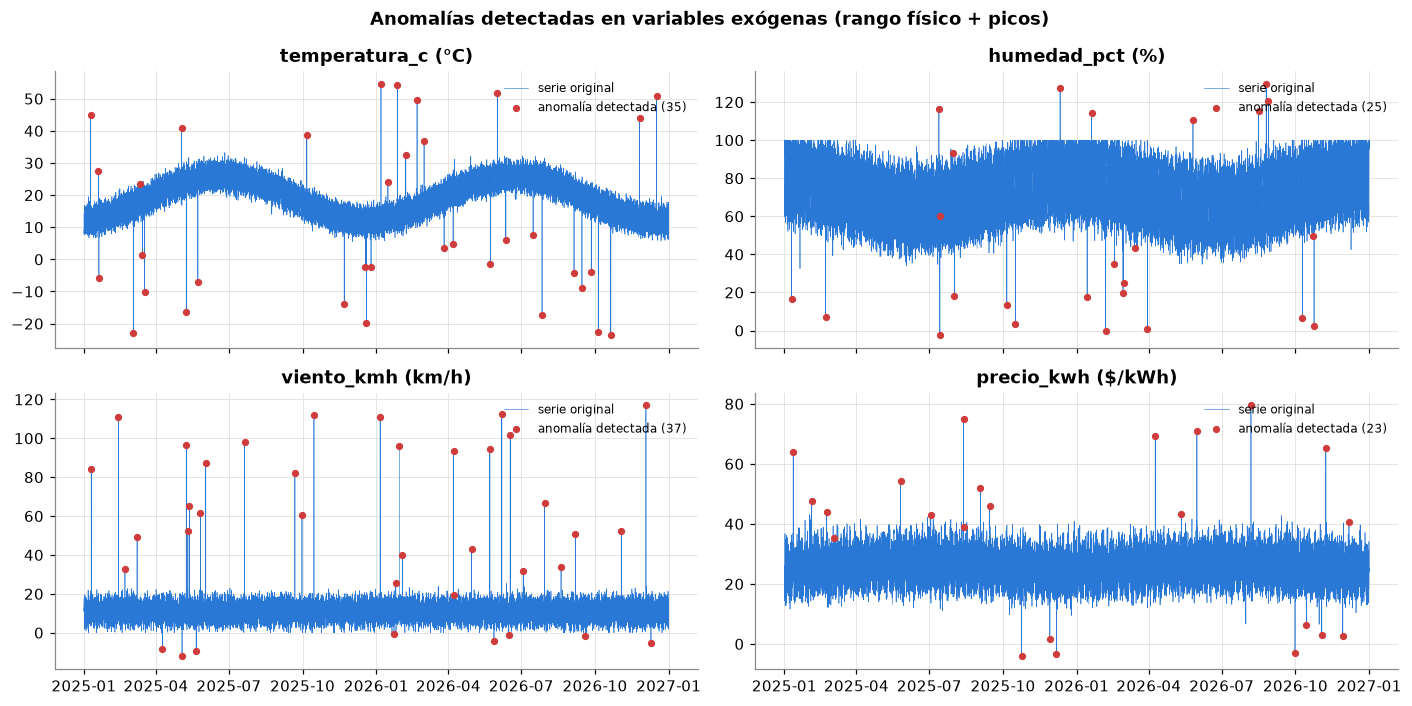

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6.5), sharex=True)
units = {"temperatura_c": "°C", "humedad_pct": "%", "viento_kmh": "km/h", "precio_kwh": "$/kWh"}
for ax, col in zip(axes.flat, SPIKE_CHECK_COLS):
    flagged = anomaly_masks[col]
    ax.plot(df_before["timestamp"], df_before[col], color=COLOR_MAIN, linewidth=0.4, label="serie original")
    ax.scatter(df_before.loc[flagged, "timestamp"], df_before.loc[flagged, col], s=14, color=COLOR_ANOMALY,
               zorder=3, label=f"anomalía detectada ({int(flagged.sum())})")
    ax.set_title(f"{col} ({units[col]})")
    ax.legend(loc="upper right", fontsize=8, frameon=False)
fig.suptitle("Anomalías detectadas en variables exógenas (rango físico + picos)", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "cleaning_exogenous_anomalies.png", bbox_inches="tight")
plt.show()

## 8. Anomalías en la demanda: consistencia con `demanda_objetivo`

El dataset registra **dos veces** la demanda de cada hora:

- `demanda_mw` en la fila *t* (demanda de la hora *t*), y
- `demanda_objetivo` en la fila *t − 1* (la demanda de la **siguiente** hora, que es el target del problema).

Por definición deben coincidir: `demanda_mw(t) = demanda_objetivo(t−1)`. Esto se verifica abajo.

> ⚠️ Esto también confirma que **`demanda_objetivo` es información futura**: nunca puede usarse como entrada del modelo, solo como target.

In [15]:
previous_target = df["demanda_objetivo"].shift(1)
comparable = previous_target.notna() & df["demanda_mw"].notna()
matches = (df["demanda_mw"] - previous_target).abs().le(0.005) & comparable
demand_mismatch = comparable & ~matches
print(f"Coincidencias exactas: {matches.sum():,} de {comparable.sum():,} "
      f"({matches.sum() / comparable.sum():.2%})")
print(f"Discrepancias: {demand_mismatch.sum()}")

demand_scores = modified_zscore(df["demanda_mw"])
target_scores = modified_zscore(df["demanda_objetivo"])
evidence = pd.DataFrame({
    "timestamp": df["timestamp"],
    "demanda_mw(t)": df["demanda_mw"],
    "demanda_objetivo(t-1)": previous_target,
    "z_mod demanda_mw": demand_scores.round(2),
    "z_mod demanda_objetivo(t-1)": target_scores.shift(1).round(2),
})[demand_mismatch]
evidence.sort_values("z_mod demanda_mw")

Coincidencias exactas: 17,479 de 17,519 (99.77%)
Discrepancias: 40


,timestamp,demanda_mw(t),demanda_objetivo(t-1),z_mod demanda_mw,z_mod demanda_objetivo(t-1)
11228,2026-04-13 20:00:00,94.90,776.50,-8.04,1.42
15446,2026-10-06 14:00:00,132.90,496.88,-7.49,-2.31
16530,2026-11-20 18:00:00,94.58,704.57,-6.73,1.68
4138,2025-06-22 10:00:00,160.66,524.27,-6.47,-1.38
5526,2025-08-19 06:00:00,261.68,770.05,-6.04,1.00
12081,2026-05-19 09:00:00,335.96,682.76,-5.65,-0.79
13168,2026-07-03 16:00:00,329.16,694.87,-5.27,-0.15
14147,2026-08-13 11:00:00,357.24,549.92,-4.96,-2.27
8049,2025-12-02 09:00:00,340.47,651.09,-3.99,0.08
5863,2025-09-02 07:00:00,480.47,714.46,-2.93,0.29


**¿Cuál de los dos registros es el anómalo?** La evidencia apunta siempre a `demanda_mw`:

- En las discrepancias, `demanda_mw` toma valores como 95 MW o 1 776 MW (z modificado hasta ±16), mientras que `demanda_objetivo(t−1)` es coherente con las horas vecinas (|z| < 2.6 en todos los casos).
- La serie `demanda_objetivo` completa no tiene picos fuera de lo normal (ver la celda siguiente: sus pocos valores con |z| > 3.5 son picos de demanda de verano que **también** aparecen idénticos en `demanda_mw`, es decir, son reales y están confirmados por ambos registros).
- 11 de las 40 discrepancias **no serían detectables** con un z-score (|z| < 3.5): solo la regla de consistencia las encuentra.

**Regla:** cuando `demanda_mw(t) ≠ demanda_objetivo(t−1)`, el valor de `demanda_mw(t)` se marca como anómalo y se **reconcilia con el registro redundante** `demanda_objetivo(t−1)`.

**Justificación:** esto **no es inventar un valor**: es la misma magnitud física (demanda de la hora *t*) ya registrada en el propio dataset. Además, no hay fuga de información: el valor de `demanda_mw(t)` es conocido en el instante *t*.

> Nota: si se aplicara solo el z-score se borrarían como "anomalías" 5 picos reales de demanda (confirmados por ambos registros) y se dejarían pasar 11 anomalías verdaderas. La regla de consistencia es más precisa.

In [16]:
real_peaks = target_scores.abs().gt(SPIKE_THRESHOLD)
print("Valores de demanda_objetivo con |z| > 3.5 (también presentes en demanda_mw de la hora siguiente):")
display(pd.DataFrame({
    "timestamp_objetivo": df["timestamp"] + pd.Timedelta(hours=1),
    "demanda_objetivo(t)": df["demanda_objetivo"],
    "demanda_mw(t+1)": df["demanda_mw"].shift(-1),
    "z_mod": target_scores.round(2),
})[real_peaks])

anomaly_masks["demanda_mw"] = anomaly_masks["demanda_mw"] | demand_mismatch
record_changes(df, demand_mismatch, "demanda_mw", "reconciliado con demanda_objetivo(t-1)", previous_target)
df.loc[demand_mismatch, "demanda_mw"] = previous_target[demand_mismatch]
log_step("8", "Reconciliar demanda_mw(t) con demanda_objetivo(t-1)",
         "Mismo valor físico registrado dos veces; se toma el registro coherente (observado, no inventado)",
         demand_mismatch.sum())

Valores de demanda_objetivo con |z| > 3.5 (también presentes en demanda_mw de la hora siguiente):


,timestamp_objetivo,demanda_objetivo(t),demanda_mw(t+1),z_mod
4434,2025-07-04 19:00:00,893.16,893.16,3.69
4435,2025-07-04 20:00:00,898.48,898.48,3.81
4938,2025-07-25 19:00:00,927.31,927.31,4.06
5555,2025-08-20 12:00:00,439.60,439.60,-3.65
13338,2026-07-10 19:00:00,885.24,885.24,3.52


[8] Reconciliar demanda_mw(t) con demanda_objetivo(t-1): 40 registros afectados


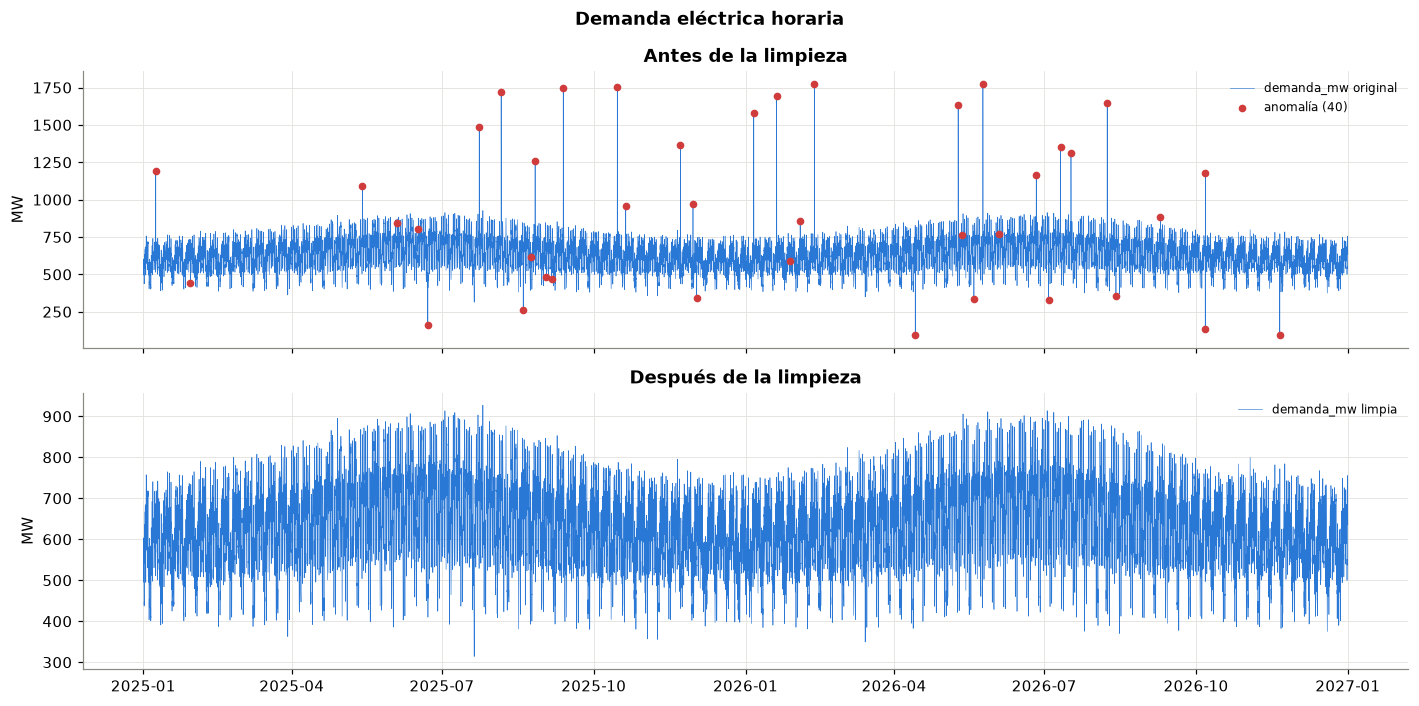

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
axes[0].plot(df_before["timestamp"], df_before["demanda_mw"], color=COLOR_MAIN, linewidth=0.4, label="demanda_mw original")
axes[0].scatter(df_before.loc[demand_mismatch, "timestamp"], df_before.loc[demand_mismatch, "demanda_mw"],
                s=16, color=COLOR_ANOMALY, zorder=3, label=f"anomalía ({int(demand_mismatch.sum())})")
axes[0].set_title("Antes de la limpieza")
axes[0].set_ylabel("MW")
axes[0].legend(loc="upper right", fontsize=8, frameon=False)
axes[1].plot(df["timestamp"], df["demanda_mw"], color=COLOR_MAIN, linewidth=0.4, label="demanda_mw limpia")
axes[1].set_title("Después de la limpieza")
axes[1].set_ylabel("MW")
axes[1].legend(loc="upper right", fontsize=8, frameon=False)
fig.suptitle("Demanda eléctrica horaria", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "cleaning_demand_before_after.png", bbox_inches="tight")
plt.show()

## 9. Valores faltantes en variables exógenas

Después de los pasos 6–7, las variables exógenas tienen `NaN` por dos motivos: celdas vacías originales y anomalías eliminadas.

**Alternativa estricta descartada – eliminar las ventanas que contienen `NaN`:** las horas afectadas están repartidas a lo largo de los dos años y cada una invalida todas las ventanas que la contienen. La tabla de abajo cuantifica la pérdida: alrededor de una cuarta parte de las ventanas de 12 h, casi la mitad de las de 24 h y dos tercios de las de 48 h. Además, cada tamaño de ventana se entrenaría con un conjunto distinto de datos, lo que haría injusta la comparación 12/24/48 que pide el taller.

**Regla adoptada – arrastre del último valor observado (*forward fill*), máximo 3 horas:**

- Es **causal**: solo usa el pasado. Es exactamente lo que haría un sistema en producción cuando un sensor no reporta: usar la última lectura válida. Así el modelo se entrena en las mismas condiciones en las que operará.
- **No fabrica números:** reutiliza una medición que realmente se observó una hora antes.
- Los huecos son cortos (máximo 2–3 h seguidas) y estas variables cambian lentamente de una hora a la siguiente, por lo que la persistencia es el supuesto más conservador.
- Se descartó la interpolación lineal porque usa el valor de la hora siguiente (información futura).
- El límite de 3 h evita "congelar" una variable durante periodos largos; si quedara algún `NaN`, las ventanas que lo contengan se descartarían al crear las secuencias.

In [18]:
MAX_FILL_HOURS = 3


def longest_nan_run(series):
    is_nan = series.isna().astype(int)
    return int(is_nan.groupby((is_nan != is_nan.shift()).cumsum()).sum().max())


missing_summary = pd.DataFrame({
    "faltantes_originales": df_before[EXOGENOUS_COLS].isna().sum(),
    "anomalias_marcadas": pd.Series({col: int(anomaly_masks.get(col, pd.Series(False)).sum()) for col in EXOGENOUS_COLS}),
    "nan_totales": df[EXOGENOUS_COLS].isna().sum(),
    "racha_max_nan_h": pd.Series({col: longest_nan_run(df[col]) for col in EXOGENOUS_COLS}),
})
display(missing_summary)

rows_with_nan = df[EXOGENOUS_COLS].isna().any(axis=1)
print(f"Horas con al menos un NaN en exógenas: {rows_with_nan.sum()}")
lost_windows = {}
for window in (12, 24, 48):
    window_has_nan = rows_with_nan.astype(int).rolling(window).sum().gt(0).iloc[window - 1:]
    lost_windows[f"{window} h"] = f"{window_has_nan.mean():.0%}"
display(pd.Series(lost_windows, name="ventanas que se perderían si se descartaran").to_frame())

,faltantes_originales,anomalias_marcadas,nan_totales,racha_max_nan_h
temperatura_c,70,35,105,2
humedad_pct,70,25,95,1
viento_kmh,70,37,107,2
radiacion_wm2,0,0,0,0
precipitacion_mm,0,0,0,0
precio_kwh,70,23,93,2


Horas con al menos un NaN en exógenas: 397


,ventanas que se perderían si se descartaran
12 h,24%
24 h,43%
48 h,68%


In [19]:
for col in EXOGENOUS_COLS:
    filled = df[col].ffill(limit=MAX_FILL_HOURS)
    was_filled = df[col].isna() & filled.notna()
    record_changes(df, was_filled, col, "forward fill (último valor observado)", filled)
    df[col] = filled
    log_step("9", f"Forward fill de {col} (máx. {MAX_FILL_HOURS} h)",
             "Relleno causal con la última medición observada; sin información futura", was_filled.sum())

print("\nNaN restantes en exógenas:", int(df[EXOGENOUS_COLS].isna().sum().sum()))

[9] Forward fill de temperatura_c (máx. 3 h): 105 registros afectados
[9] Forward fill de humedad_pct (máx. 3 h): 95 registros afectados
[9] Forward fill de viento_kmh (máx. 3 h): 107 registros afectados
[9] Forward fill de radiacion_wm2 (máx. 3 h): 0 registros afectados
[9] Forward fill de precipitacion_mm (máx. 3 h): 0 registros afectados
[9] Forward fill de precio_kwh (máx. 3 h): 93 registros afectados

NaN restantes en exógenas: 0


## 10. Target (`demanda_objetivo`)

Solo hay un faltante: la última hora del dataset (2026-12-31 23:00). Su objetivo sería la demanda de 2027-01-01 00:00, que **no existe en los datos**.

**Regla:** se conserva la fila (su `demanda_mw` es historia válida) pero **no se usa como muestra de entrenamiento/evaluación**; el script de modelado descarta las ventanas cuyo target es `NaN`. No se rellena porque cualquier valor sería inventado.

In [20]:
target_missing = df["demanda_objetivo"].isna()
print(df.loc[target_missing, ["timestamp", "demanda_mw", "demanda_objetivo"]])
log_step("10", "Target faltante en la última hora: no se usa como muestra",
         "No existe la hora siguiente en el dataset; rellenarlo sería inventar", target_missing.sum())

                timestamp  demanda_mw  demanda_objetivo
17519 2026-12-31 23:00:00      635.14               NaN
[10] Target faltante en la última hora: no se usa como muestra: 1 registros afectados


## 11. Validación final

Se comprueban automáticamente todas las condiciones que debe cumplir el dataset limpio. Si alguna falla, el notebook se detiene.

In [21]:
checks = {
    "sin filas duplicadas": not df.duplicated().any(),
    "sin timestamps repetidos": not df["timestamp"].duplicated().any(),
    "orden cronológico estricto": df["timestamp"].is_monotonic_increasing,
    "una fila por hora (sin huecos)": len(df) == len(expected_hours),
    "sin NaN en variables de entrada": not df.drop(columns="demanda_objetivo").isna().any().any(),
    "humedad en [0, 100]": df["humedad_pct"].between(0, 100).all(),
    "viento, radiación y lluvia >= 0": (df[["viento_kmh", "radiacion_wm2", "precipitacion_mm"]] >= 0).all().all(),
    "precio > 0": (df["precio_kwh"] > 0).all(),
    "periodo_dia con 4 categorías coherentes con hora": (df["periodo_dia"] == df["hora"].map(PERIOD_BY_HOUR)).all(),
    "demanda_objetivo(t) == demanda_mw(t+1)": (df["demanda_objetivo"] - df["demanda_mw"].shift(-1)).abs().fillna(0).le(0.005).all(),
    "un único target faltante (última hora)": df["demanda_objetivo"].isna().sum() == 1 and pd.isna(df["demanda_objetivo"].iloc[-1]),
}
validation = pd.Series(checks, name="cumple")
display(validation.to_frame())
assert validation.all(), "Alguna validación falló"

,cumple
sin filas duplicadas,True
sin timestamps repetidos,True
orden cronológico estricto,True
una fila por hora (sin huecos),True
sin NaN en variables de entrada,True
"humedad en [0, 100]",True
"viento, radiación y lluvia >= 0",True
precio > 0,True
periodo_dia con 4 categorías coherentes con hora,True
demanda_objetivo(t) == demanda_mw(t+1),True


In [22]:
comparison_cols = ["demanda_mw", "temperatura_c", "humedad_pct", "viento_kmh", "precio_kwh"]
before_stats = df_before[comparison_cols].describe().T[["min", "mean", "max", "std"]].add_suffix("_antes")
after_stats = df[comparison_cols].describe().T[["min", "mean", "max", "std"]].add_suffix("_despues")
pd.concat([before_stats, after_stats], axis=1).round(2)

,min_antes,mean_antes,max_antes,std_antes,min_despues,mean_despues,max_despues,std_despues
demanda_mw,94.58,634.75,1776.21,102.21,314.12,634.06,927.31,97.73
temperatura_c,-23.54,18.99,54.69,5.80,5.53,19.00,33.26,5.69
humedad_pct,-2.35,71.99,129.69,14.88,32.56,72.03,100.00,14.76
viento_kmh,-12.20,11.05,117.05,4.97,0.00,10.96,25.33,4.12
precio_kwh,-4.17,24.64,79.58,5.44,6.55,24.62,43.09,5.33


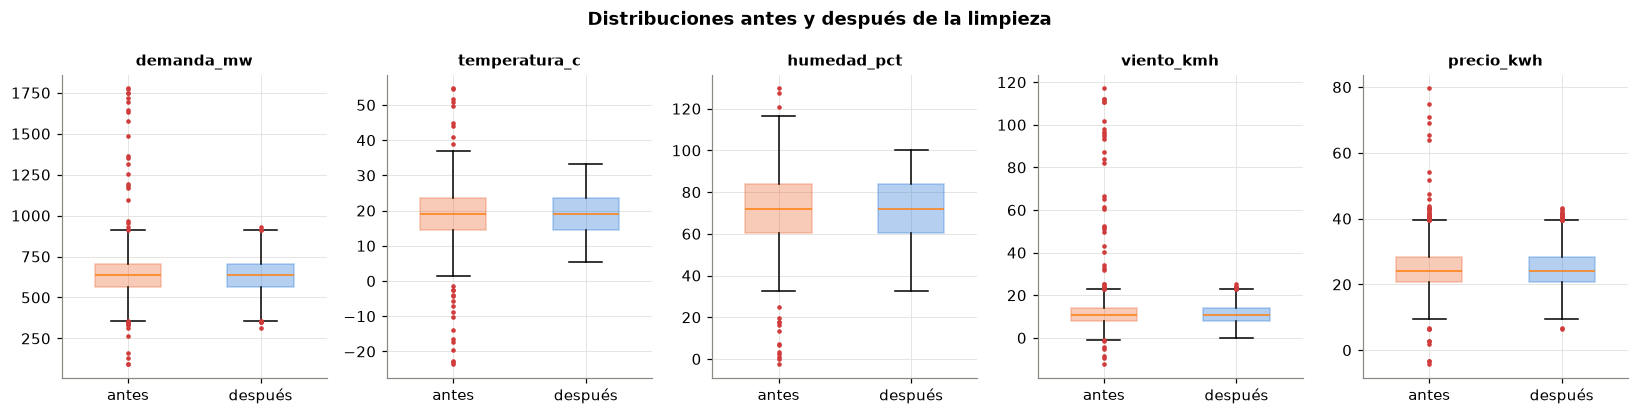

In [23]:
fig, axes = plt.subplots(1, len(comparison_cols), figsize=(15, 3.8))
for ax, col in zip(axes, comparison_cols):
    box = ax.boxplot([df_before[col].dropna(), df[col]], tick_labels=["antes", "después"], widths=0.5,
                     patch_artist=True, flierprops={"markersize": 2, "markerfacecolor": COLOR_ANOMALY,
                                                    "markeredgecolor": COLOR_ANOMALY})
    for patch, color in zip(box["boxes"], [COLOR_SECONDARY, COLOR_MAIN]):
        patch.set_facecolor(color)
        patch.set_alpha(0.35)
        patch.set_edgecolor(color)
    ax.set_title(col, fontsize=10)
fig.suptitle("Distribuciones antes y después de la limpieza", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "cleaning_boxplots_before_after.png", bbox_inches="tight")
plt.show()

Los puntos que siguen apareciendo fuera de las cajas "después" son valores **plausibles** del extremo de la distribución (p. ej. picos de demanda de las 19 h en verano o tardes calurosas), no errores: ya pasaron la regla física, la de picos contextuales y, en el caso de la demanda, la de consistencia entre registros. Eliminarlos quitaría al modelo justamente los casos de demanda alta que más interesa predecir.

## 12. Guardar resultados

In [24]:
df.to_csv(CLEAN_PATH, index=False, encoding="utf-8")

summary_df = pd.DataFrame(cleaning_log)
summary_df.to_csv(REPORT_DIR / "cleaning_summary.csv", index=False, encoding="utf-8")

changes_df = pd.concat(change_records, ignore_index=True).sort_values(["timestamp", "variable"])
changes_df.to_csv(REPORT_DIR / "cleaning_changes.csv", index=False, encoding="utf-8")

print(f"Dataset limpio      : {CLEAN_PATH}  ({len(df):,} filas x {df.shape[1]} columnas)")
print(f"Resumen de reglas   : {REPORT_DIR / 'cleaning_summary.csv'}")
print(f"Cambios registrados : {REPORT_DIR / 'cleaning_changes.csv'}  ({len(changes_df):,} valores)")
summary_df

Dataset limpio      : data\energy_demand_clean.csv  (17,520 filas x 15 columnas)
Resumen de reglas   : outputs\reports\cleaning_summary.csv
Cambios registrados : outputs\reports\cleaning_changes.csv  (620 valores)


,paso,regla,justificacion,registros_afectados
0,1,Normalizar texto de periodo_dia (strip + minús...,Variantes de formato de la misma categoría gen...,80
1,3,Eliminar filas duplicadas exactas,Copias idénticas duplican el peso de una hora ...,30
2,4,Ordenar cronológicamente (filas que retrocedía...,Las secuencias LSTM requieren orden temporal e...,8773
3,5,Recalcular periodo_dia desde hora,Etiqueta derivada de la hora; las contradiccio...,60
4,6,Rango físico de humedad_pct,Valor físicamente imposible,9
5,6,Rango físico de viento_kmh,Valor físicamente imposible,8
6,6,Rango físico de radiacion_wm2,Valor físicamente imposible,0
7,6,Rango físico de precipitacion_mm,Valor físicamente imposible,0
8,6,Rango físico de precio_kwh,Valor físicamente imposible,3
9,6,Rango físico de demanda_mw,Valor físicamente imposible,0


In [25]:
changes_df.groupby(["regla", "variable"]).size().rename("valores").to_frame()

valores
regla                                          variable              
7a desviación del nivel local |M| > 3.5 -> NaN humedad_pct          4
                                               precio_kwh          18
                                               temperatura_c       33
                                               viento_kmh          28
7b pico aislado S > 3.5 -> NaN                 humedad_pct         12
                                               precio_kwh           2
                                               temperatura_c        2
                                               viento_kmh           1
forward fill (último valor observado)          humedad_pct         95
                                               precio_kwh          93
                                               temperatura_c      105
                                               viento_kmh         107
fuera de rango físico -> NaN                   humedad_pct          9
                                               precio_kwh           3
                                               viento_kmh           8
periodo_dia derivado de hora                   periodo_dia         60
reconciliado con demanda_objetivo(t-1)         demanda_mw          40

## Resumen de la limpieza

| # | Problema | Regla aplicada | ¿Se inventaron valores? |
|---|---|---|---|
| 1 | Inconsistencias de texto en `periodo_dia` | strip + minúsculas + NFC | No (solo formato) |
| 3 | Filas duplicadas | eliminar copias exactas (sin conflictos) | No |
| 4 | Desorden temporal | ordenar por `timestamp`; serie completa de 17 520 h | No |
| 5 | `periodo_dia` contradictorio con `hora` | derivarlo de `hora` (0–5 madrugada, 6–11 mañana, 12–17 tarde, 18–23 noche) | No (regla determinista) |
| 6 | Valores físicamente imposibles | marcar `NaN` | No |
| 7 | Picos contextuales en clima y precio | 7a: z-score modificado > 3.5 vs mediana móvil de 25 h; 7b: pico aislado > 3.5 → `NaN` | No |
| 8 | Anomalías en `demanda_mw` | consistencia con `demanda_objetivo(t−1)`; reconciliar con el registro observado | No (valor observado en el dataset) |
| 9 | Faltantes en exógenas | *forward fill* causal ≤ 3 h | No se fabrica: se arrastra la última medición real |
| 10 | Target faltante (última hora) | se excluye como muestra | No |

**Implicaciones para el modelado (Parte 2):**

- `demanda_objetivo` es exactamente la demanda de la hora siguiente → es el **target** y **nunca** puede ser entrada.
- Entradas permitidas en cada paso de la ventana: `demanda_mw`, clima, precio y calendario de las horas *t−n+1 … t*.
- La división train/validación/test y la normalización se hacen **después**, en orden cronológico y con parámetros calculados solo sobre entrenamiento.